# ch307 — Stochastic Gradient Descent

## 1. Why stochastic?

Full-batch gradient descent computes the exact gradient over all $N$ training samples:
$$\nabla_\theta \mathcal{L} = \frac{1}{N}\sum_{i=1}^N \nabla_\theta \ell_i$$

This is expensive ($O(N)$ per step) and offers no benefit once the gradient direction
is well-estimated. **Stochastic Gradient Descent (SGD)** estimates the gradient from a
mini-batch of $B \ll N$ samples:

$$\theta \leftarrow \theta - \eta \cdot \hat{g}_B, \quad \hat{g}_B = \frac{1}{B}\sum_{i \in \text{batch}} \nabla_\theta \ell_i$$

The estimate is noisy but unbiased: $\mathbb{E}[\hat{g}_B] = \nabla_\theta \mathcal{L}$.

*(Gradient descent: ch212. Expectation: ch249.)*

---

## 2. Why noise helps

Counter-intuitively, gradient noise has benefits:
- It escapes **sharp minima** (which tend to generalise poorly) and settles in **flat minima**
  (which tend to generalise well).
- It prevents the optimiser from overfitting to noise in early training.
- Theoretical analysis (Mandt et al., 2017) shows SGD noise acts as implicit regularisation.

---

## 3. SGD variants

| Variant | Update rule | Key property |
|---------|-------------|--------------|
| Vanilla SGD | $\theta \leftarrow \theta - \eta g$ | Simple, no memory |
| SGD + Momentum | $v \leftarrow \mu v - \eta g$; $\theta \leftarrow \theta + v$ | Dampens oscillation, accelerates |
| Nesterov | Lookahead gradient | Better convergence guarantees |

Momentum accumulates a velocity vector $v$, allowing the optimiser to accelerate
in consistent gradient directions and slow down when direction oscillates.

*(Adam and adaptive methods: ch312.)*

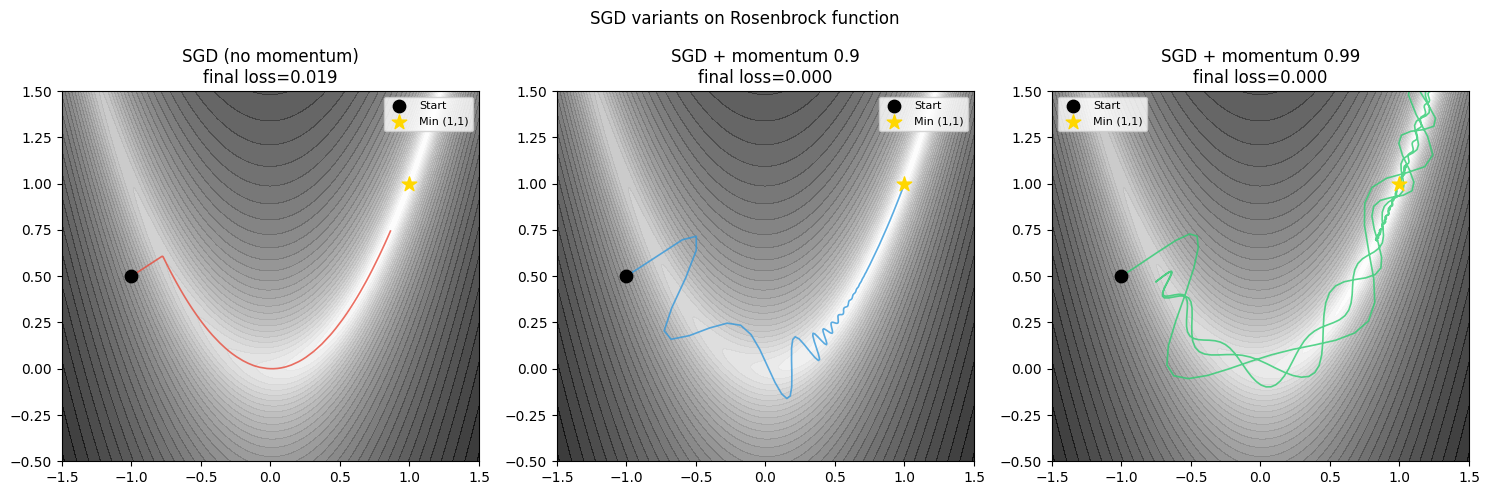

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def rosenbrock(params):
    """Classic test function: minimum at (1,1), banana-shaped valley."""
    x, y = params
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(params):
    x, y = params
    dfdx = -2*(1 - x) - 400*x*(y - x**2)
    dfdy = 200*(y - x**2)
    return np.array([dfdx, dfdy])


def run_sgd(start, lr, momentum=0.0, n_steps=2000, noise=0.01, seed=0):
    rng = np.random.default_rng(seed)
    params = np.array(start, dtype=float)
    v = np.zeros_like(params)
    history = [params.copy()]
    for _ in range(n_steps):
        g = rosenbrock_grad(params) + rng.normal(0, noise, 2)  # simulate mini-batch noise
        v = momentum * v - lr * g
        params = params + v
        history.append(params.copy())
    return np.array(history)


configs = [
    ('SGD (no momentum)', 0.001, 0.0, '#e74c3c'),
    ('SGD + momentum 0.9', 0.001, 0.9, '#3498db'),
    ('SGD + momentum 0.99', 0.0005, 0.99, '#2ecc71'),
]

# Rosenbrock landscape
xs = np.linspace(-1.5, 1.5, 400)
ys = np.linspace(-0.5, 1.5, 400)
X, Y = np.meshgrid(xs, ys)
Z = (1 - X)**2 + 100*(Y - X**2)**2
Z_log = np.log1p(Z)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
start = [-1.0, 0.5]

for ax, (name, lr, mu, color) in zip(axes, configs):
    hist = run_sgd(start, lr, mu, n_steps=3000, noise=0.05)
    ax.contourf(X, Y, Z_log, levels=40, cmap='gray_r', alpha=0.8)
    ax.plot(hist[:, 0], hist[:, 1], color=color, lw=1.2, alpha=0.8)
    ax.scatter(*start, color='black', s=80, zorder=5, label='Start')
    ax.scatter(1, 1, color='gold', s=120, marker='*', zorder=5, label='Min (1,1)')
    ax.set_title(f'{name}\nfinal loss={rosenbrock(hist[-1]):.3f}')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.legend(fontsize=8)

plt.suptitle('SGD variants on Rosenbrock function', fontsize=12)
plt.tight_layout()
plt.savefig('ch307_sgd.png', dpi=120)
plt.show()

## 4. Practical SGD settings

| Hyperparameter | Typical range | Effect |
|---|---|---|
| Learning rate $\eta$ | 0.001 – 0.1 | Step size; most critical hyperparameter |
| Momentum $\mu$ | 0.9 – 0.99 | Higher = more history, faster in smooth valleys |
| Batch size $B$ | 32 – 512 | Larger = less noise, more parallelism, needs higher LR |

**Batch size scaling rule:** When multiplying $B$ by $k$, multiply $\eta$ by $\sqrt{k}$
(or linearly for short training runs). This keeps gradient noise variance constant.

---

## 5. Gradient clipping

For RNNs and deep networks, gradients can explode *(ch306)*. Clipping caps gradient norm:

$$g \leftarrow g \cdot \min\left(1, \frac{\text{clip\_norm}}{\|g\|}\right)$$

This preserves direction while bounding magnitude. Common values: `clip_norm = 1.0`.

---

## 6. Summary

- SGD uses mini-batch gradient estimates: unbiased, noisy, and computationally cheap.
- Momentum accumulates gradient history to accelerate in consistent directions.
- Batch size and learning rate are coupled: scaling one requires scaling the other.
- Gradient clipping prevents explosions in deep/recurrent networks.

---

## 7. Forward and backward references

**Used here:** gradient descent *(ch212)*, optimisation landscapes *(ch213)*,
backpropagation gradients *(ch306)*, expectation *(ch249)*.

**This will reappear in ch312 — Optimisers: Adam, RMSProp, Momentum**, where adaptive
learning rates eliminate the need to hand-tune $\eta$ per parameter, and in ch334 —
Project: Neural Net from Scratch, where SGD with momentum is implemented end-to-end.